In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, f1_score, average_precision_score

import torch
from torch.nn import BCEWithLogitsLoss
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EvalPrediction,
    EarlyStoppingCallback
)

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit, MultilabelStratifiedKFold

torch.manual_seed(4262)
np.random.seed(4262)

## Load Dataset

In [2]:
train_df = pd.read_csv('../data/model_training_data.csv')
train_df.head()

,title,selftext,Assignee,feas_pa,feas_ka,feas_cr,feas_sr
0,"Accepted a Job, Relocated, and Then Got My Off...","In other words, they filled the role internall...",Overlap,1.0,1.0,3.0,1.0
1,I Am a Fraud and ChatGPT Is My Brain,literally everything. uni? fake. career pat...,Overlap,4.0,4.0,4.0,1.0
2,Wow interviews suck more now,"This makes you look bad"" and I replied ""if you...",Overlap,1.0,1.0,1.0,2.0
3,Think I'm about to turn Netflix down. Am I crazy?,Did all 7 interviews down and got an offer. 5...,Overlap,1.0,1.0,1.0,1.0
4,"The bar is absolutely, insanely high.",Interviewed at a unicorn tech company for inte...,Overlap,1.0,1.0,1.0,1.0


In [ ]:
# Convert to binary labels (0 for <3, 1 for >=3)
train_df['feas_pa'] = (train_df['feas_pa'] >= 3).astype(int)
train_df['feas_ka'] = (train_df['feas_ka'] >= 3).astype(int)
train_df['feas_cr'] = (train_df['feas_cr'] >= 3).astype(int)
train_df['feas_sr'] = (train_df['feas_sr'] >= 3).astype(int)
train_df.head()

,title,selftext,Assignee,feas_pa,feas_ka,feas_cr,feas_sr
0,"Accepted a Job, Relocated, and Then Got My Off...","In other words, they filled the role internall...",Overlap,0,0,1,0
1,I Am a Fraud and ChatGPT Is My Brain,literally everything. uni? fake. career pat...,Overlap,1,1,1,0
2,Wow interviews suck more now,"This makes you look bad"" and I replied ""if you...",Overlap,0,0,0,0
3,Think I'm about to turn Netflix down. Am I crazy?,Did all 7 interviews down and got an offer. 5...,Overlap,0,0,0,0
4,"The bar is absolutely, insanely high.",Interviewed at a unicorn tech company for inte...,Overlap,0,0,0,0


In [4]:
# Print class distribution percentages
print("Class distribution for feas_pa:")
print(train_df['feas_pa'].value_counts(normalize=True) * 100)
print("\nClass distribution for feas_ka:")
print(train_df['feas_ka'].value_counts(normalize=True) * 100)
print("\nClass distribution for feas_cr:")
print(train_df['feas_cr'].value_counts(normalize=True) * 100)
print("\nClass distribution for feas_sr:")
print(train_df['feas_sr'].value_counts(normalize=True) * 100)

Class distribution for feas_pa:
feas_pa
0    73.739496
1    26.260504
Name: proportion, dtype: float64

Class distribution for feas_ka:
feas_ka
0    88.445378
1    11.554622
Name: proportion, dtype: float64

Class distribution for feas_cr:
feas_cr
0    82.563025
1    17.436975
Name: proportion, dtype: float64

Class distribution for feas_sr:
feas_sr
0    96.428571
1     3.571429
Name: proportion, dtype: float64


In [5]:
test_df = pd.read_csv('../data/form_responses.csv')
test_df.head()

,timestamp,consent,demo_gender,demo_area_of_study,demo_honours_class,demo_job_search_status,demo_num_prior_interns,demo_financial_urgency,feas_pa1,feas_pa2,...,feas_sr3,feas_sr4,bhv_apps_4_wks,bhv_itvs_4_wks,bhv_job_update_check_daily,ac2,bhv_app_duration,bhv_app_status_check_daily,bhv_app_avoidance_weekly,bhv_job_search_exp
0,2/24/2026 8:47:57,I agree,Male,Computing and Data,Honours (Highest Distinction),Actively applying,1-2,5,5,2,...,1,2,31+,2 - 3,1 - 2,0,<10 min,1 - 2,1 - 2,Not knowing what the companies want. Sometimes...
1,2/24/2026 11:51:05,I agree,Female,Computing and Data,Honours (Distinction),Actively applying,1-2,3,5,4,...,4,2,6 - 15,1,1 - 2,0,10 - 30 min,0,3 - 5,I dl being on LinkedIn sometimes it’s a luck g...
2,2/24/2026 11:55:42,I agree,Female,Design & Engineering,Honours (Highest Distinction),Actively applying,1-2,2,4,2,...,4,2,16 - 30,0,3 - 5,0,10 - 30 min,1 - 2,1 - 2,1. Not making good progress - not trying hard ...
3,2/24/2026 12:07:31,I agree,Male,Design & Engineering,Honours (Distinction),Actively applying,1-2,5,2,2,...,4,4,0,1,3 - 5,0,10 - 30 min,1 - 2,0,1. Social circle: I feel worried when I hear o...
4,2/24/2026 12:08:09,I agree,Female,Computing and Data,Honours (Distinction),Secured but still actively applying,3 and above,2,4,4,...,2,4,16 - 30,1,1 - 2,0,10 - 30 min,1 - 2,3 - 5,Seeing people get to big companies feels a lit...


In [6]:
# Compute average score for 4 dimensions
test_df['feas_pa'] = test_df[['feas_pa1', 'feas_pa2', 'feas_pa3', 'feas_pa4', 'feas_pa5']].mean(axis=1)
test_df['feas_ka'] = test_df[['feas_ka1', 'feas_ka2', 'feas_ka3', 'feas_ka4']].mean(axis=1)
test_df['feas_cr'] = test_df[['feas_cr1', 'feas_cr2', 'feas_cr3', 'feas_cr4']].mean(axis=1)
test_df['feas_sr'] = test_df[['feas_sr1', 'feas_sr2', 'feas_sr3', 'feas_sr4']].mean(axis=1)

In [7]:
# Convert to binary labels (0 for <=3, 1 for >3)
test_df['feas_pa'] = (test_df['feas_pa'] > 3).astype(int)
test_df['feas_ka'] = (test_df['feas_ka'] > 3).astype(int)
test_df['feas_cr'] = (test_df['feas_cr'] > 3).astype(int)
test_df['feas_sr'] = (test_df['feas_sr'] > 3).astype(int)
test_df.head()

,timestamp,consent,demo_gender,demo_area_of_study,demo_honours_class,demo_job_search_status,demo_num_prior_interns,demo_financial_urgency,feas_pa1,feas_pa2,...,bhv_job_update_check_daily,ac2,bhv_app_duration,bhv_app_status_check_daily,bhv_app_avoidance_weekly,bhv_job_search_exp,feas_pa,feas_ka,feas_cr,feas_sr
0,2/24/2026 8:47:57,I agree,Male,Computing and Data,Honours (Highest Distinction),Actively applying,1-2,5,5,2,...,1 - 2,0,<10 min,1 - 2,1 - 2,Not knowing what the companies want. Sometimes...,0,0,0,0
1,2/24/2026 11:51:05,I agree,Female,Computing and Data,Honours (Distinction),Actively applying,1-2,3,5,4,...,1 - 2,0,10 - 30 min,0,3 - 5,I dl being on LinkedIn sometimes it’s a luck g...,1,1,0,0
2,2/24/2026 11:55:42,I agree,Female,Design & Engineering,Honours (Highest Distinction),Actively applying,1-2,2,4,2,...,3 - 5,0,10 - 30 min,1 - 2,1 - 2,1. Not making good progress - not trying hard ...,0,1,1,1
3,2/24/2026 12:07:31,I agree,Male,Design & Engineering,Honours (Distinction),Actively applying,1-2,5,2,2,...,3 - 5,0,10 - 30 min,1 - 2,0,1. Social circle: I feel worried when I hear o...,0,1,0,1
4,2/24/2026 12:08:09,I agree,Female,Computing and Data,Honours (Distinction),Secured but still actively applying,3 and above,2,4,4,...,1 - 2,0,10 - 30 min,1 - 2,3 - 5,Seeing people get to big companies feels a lit...,1,1,1,1


In [8]:
TARGET_COLS = ['feas_pa', 'feas_ka', 'feas_cr', 'feas_sr']

def prepare_text(df):
    return np.array(df['title'].fillna('') + ' ' + df['selftext'].fillna(''))

X_full = prepare_text(train_df)
y_full = np.array(train_df[TARGET_COLS])

X_test = np.array(test_df['bhv_job_search_exp'].fillna(''))
y_test = np.array(test_df[TARGET_COLS])

# 2. Initialize the multi-label stratifier
# We use n_splits=1 because we just want a single train/val split
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 3. Generate the split
for train_index, val_index in msss.split(X_full, y_full):
    X_train, X_val = X_full[train_index], X_full[val_index]
    y_train, y_val = y_full[train_index], y_full[val_index]

print("Shapes of datasets:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Shapes of datasets:
X_train: (380,)
y_train: (380, 4)
X_val: (96,)
y_val: (96, 4)
X_test: (55,)
y_test: (55, 4)


In [9]:
def check_distributions(y_array, split_name, target_cols):
    """Prints the count and percentage of positive samples for each label."""
    percentages = np.mean(y_array, axis=0) * 100
    counts = np.sum(y_array, axis=0)
    total_samples = len(y_array)
    
    print(f"=== {split_name} Set (Total Samples: {total_samples}) ===")
    
    dist_df = pd.DataFrame({
        'Positive Count': counts,
        'Positive %': percentages
    }, index=target_cols)
    
    dist_df['Positive %'] = dist_df['Positive %'].map('{:.2f}%'.format)
    
    display(dist_df)
    print("\n")

check_distributions(y_train, "Train", TARGET_COLS)
check_distributions(y_val, "Validation", TARGET_COLS)
check_distributions(y_test, "Test", TARGET_COLS)

=== Train Set (Total Samples: 380) ===


,Positive Count,Positive %
feas_pa,100,26.32%
feas_ka,44,11.58%
feas_cr,66,17.37%
feas_sr,14,3.68%




=== Validation Set (Total Samples: 96) ===


,Positive Count,Positive %
feas_pa,25,26.04%
feas_ka,11,11.46%
feas_cr,17,17.71%
feas_sr,3,3.12%




=== Test Set (Total Samples: 55) ===


,Positive Count,Positive %
feas_pa,29,52.73%
feas_ka,37,67.27%
feas_cr,32,58.18%
feas_sr,26,47.27%


## Evaluation Function

In [10]:
def tune_threshold(y_true, y_prob):
    """Finds the optimal threshold on the validation set to maximize F1-score."""
    if np.sum(y_true) == 0:
        return 0.5  # default threshold if no positive samples

    best_t, best_f1 = 0.5, 0
    for t in np.linspace(0.05, 0.95, 50):
        preds = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

def evaluate_model(model_name, y_true_val, y_prob_val, y_true_test, y_prob_test, target_cols):
    """Standardized evaluation across Val and Test sets."""
    print(f"\n{'='*60}")
    print(f"Evaluation for: {model_name}")
    print(f"{'='*60}")

    metrics = []

    # 1. Per-label Metrics
    for i, col in enumerate(target_cols):
        # Val Metrics
        auprc_val = average_precision_score(y_true_val[:, i], y_prob_val[:, i])
        t_val = tune_threshold(y_true_val[:, i], y_prob_val[:, i])
        pred_val = (y_prob_val[:, i] >= t_val).astype(int)
        f1_val = f1_score(y_true_val[:, i], pred_val, zero_division=0)

        # Test Metrics (Strictly using Val threshold)
        auprc_test = average_precision_score(y_true_test[:, i], y_prob_test[:, i])
        pred_test = (y_prob_test[:, i] >= t_val).astype(int) 
        f1_test = f1_score(y_true_test[:, i], pred_test, zero_division=0)

        metrics.append({
            'Label': col,
            'Val AUPRC': round(auprc_val, 4),
            'Test AUPRC': round(auprc_test, 4),
            'Tuned Threshold': round(t_val, 4),
            'Val F1': round(f1_val, 4),
            'Test F1': round(f1_test, 4)
        })

    df_metrics = pd.DataFrame(metrics)

    # 2. Macro Metrics
    macro_auprc_val = average_precision_score(y_true_val, y_prob_val, average='macro')
    macro_auprc_test = average_precision_score(y_true_test, y_prob_test, average='macro')

    # Apply per-label tuned thresholds to the whole array for Macro F1
    thresholds = df_metrics['Tuned Threshold'].values
    y_pred_val_tuned = (y_prob_val >= thresholds).astype(int)
    y_pred_test_tuned = (y_prob_test >= thresholds).astype(int)

    macro_f1_val = f1_score(y_true_val, y_pred_val_tuned, average='macro', zero_division=0)
    macro_f1_test = f1_score(y_true_test, y_pred_test_tuned, average='macro', zero_division=0)

    # 3. Append Overall Row
    df_overall = pd.DataFrame([{
        'Label': 'MACRO AVERAGE',
        'Val AUPRC': round(macro_auprc_val, 4),
        'Test AUPRC': round(macro_auprc_test, 4),
        'Tuned Threshold': '-',
        'Val F1': round(macro_f1_val, 4),
        'Test F1': round(macro_f1_test, 4)
    }])

    df_final = pd.concat([df_metrics, df_overall], ignore_index=True)
    display(df_final)
    
    return df_final

## 1. TF-IDF + Logistic Regression

In [11]:
# TF-IDF is inside pipeline → fitted per CV fold
# Logistic Regression wrapped with OneVsRest

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ('clf', OneVsRestClassifier(
        LogisticRegression(
            solver='liblinear',
            class_weight='balanced',
            max_iter=1000
        )
    ))
])

In [12]:
# Important: we cannot directly do multi-label stratified CV easily with sklearn
# Practical workaround: 1) Tune using one representative label (e.g. feas_pa); 2) Then retrain full model on all labels

param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__estimator__C': [0.1, 1, 5]
}

# 1. Use MultilabelStratifiedKFold to properly stratify across ALL 4 labels
cv = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_macro', # 2. Evaluate the macro-averaged F1 score across all labels
    verbose=2,
    n_jobs=-1
)

# 3. Fit on the full multi-label array (y_train) instead of just the sliced y_strat
grid.fit(X_train, y_train) 

print("Best params:", grid.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.0s
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.0s
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time=   0.1s
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.0s
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.0s
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.0s
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time=   0.1s
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time=   0.1s
[CV] END clf__estimator__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time=   0.0s
[CV

In [13]:
# Train final model on all labels with best params
best_pipeline = grid.best_estimator_

best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [14]:
# Model 1 Prediction
y_prob_val_lr = best_pipeline.predict_proba(X_val)
y_prob_test_lr = best_pipeline.predict_proba(X_test)

# Evaluate
df_results_lr = evaluate_model(
    model_name="TF-IDF + Logistic Regression", 
    y_true_val=y_val, 
    y_prob_val=y_prob_val_lr, 
    y_true_test=y_test, 
    y_prob_test=y_prob_test_lr, 
    target_cols=TARGET_COLS
)


Evaluation for: TF-IDF + Logistic Regression


,Label,Val AUPRC,Test AUPRC,Tuned Threshold,Val F1,Test F1
0,feas_pa,0.5403,0.6784,0.4908,0.5000,0.6761
1,feas_ka,0.2828,0.6744,0.4908,0.3333,0.4000
2,feas_cr,0.3110,0.6288,0.4724,0.3656,0.7356
3,feas_sr,0.1113,0.3344,0.4724,0.1818,0.0000
4,MACRO AVERAGE,0.3114,0.5790,-,0.3452,0.4529


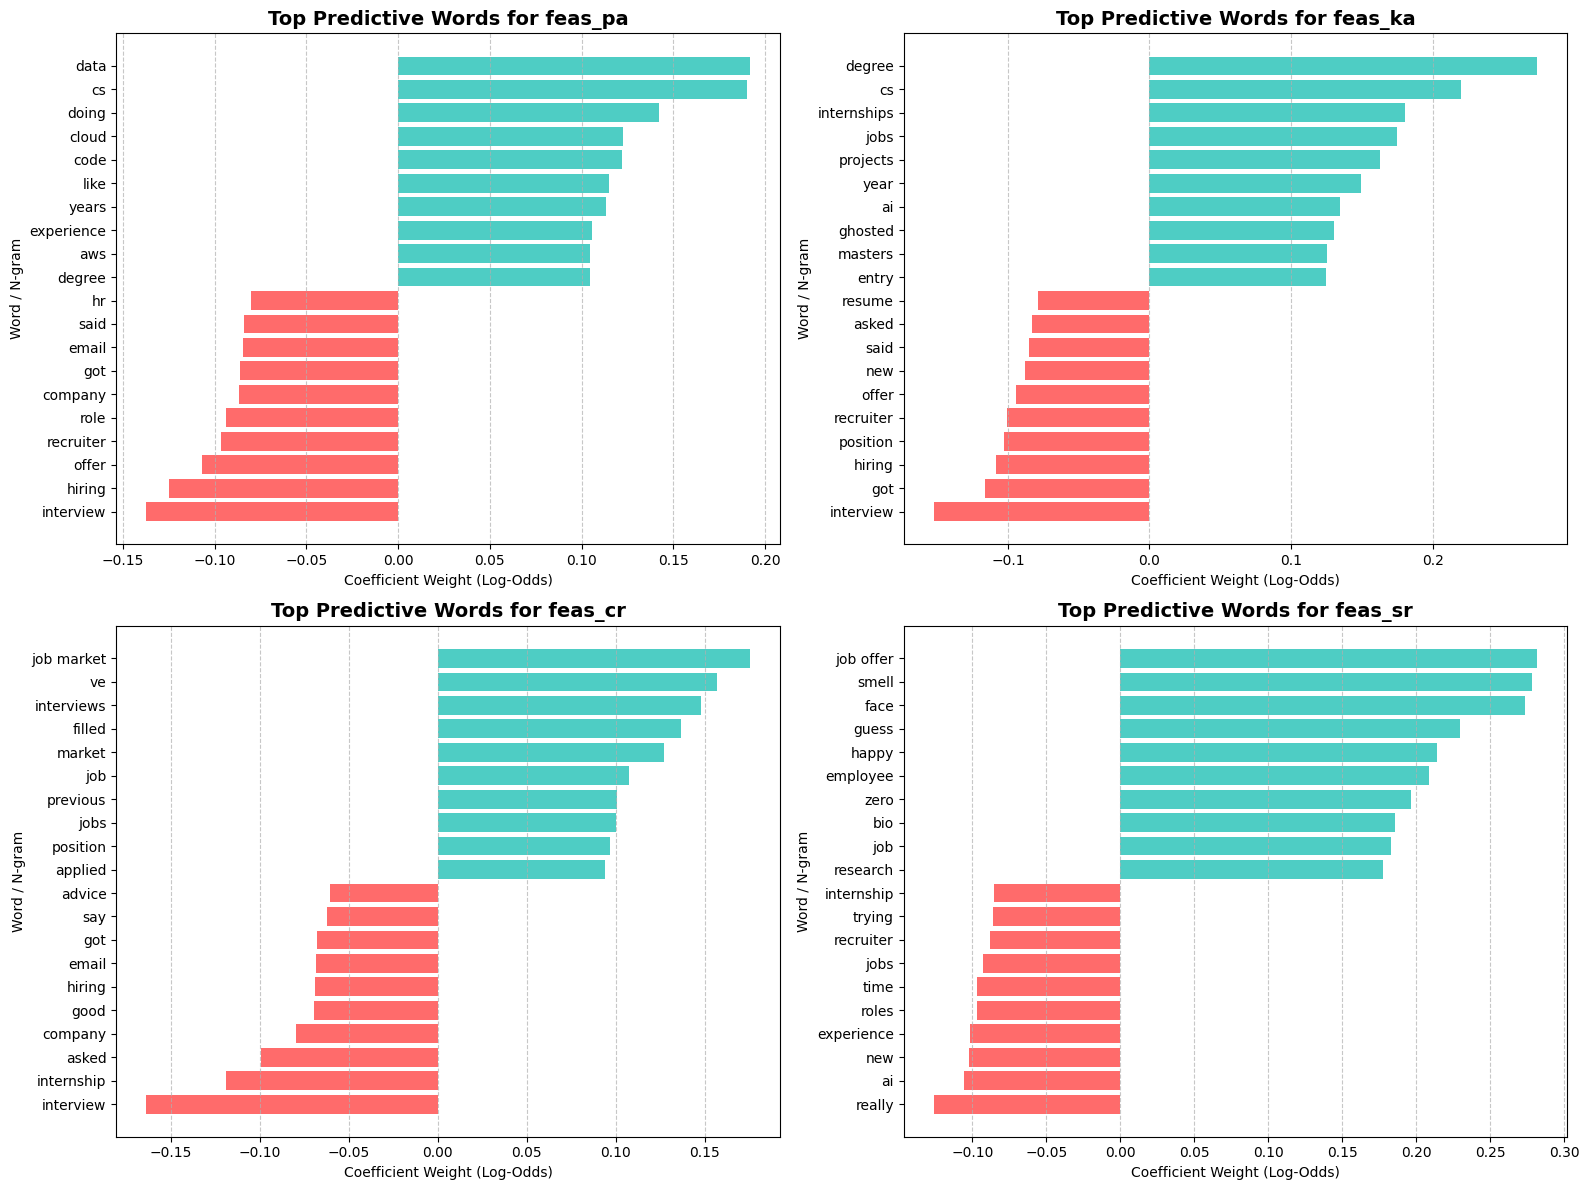

In [15]:
# Extract the fitted steps from the best pipeline
tfidf_step = best_pipeline.named_steps['tfidf']
clf_step = best_pipeline.named_steps['clf']

# Get the feature names (vocabulary)
feature_names = tfidf_step.get_feature_names_out()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Loop through each target dimension and its corresponding model
for i, target in enumerate(TARGET_COLS):
    
    # Extract coefficients for the specific label's Logistic Regression model
    coefs = clf_step.estimators_[i].coef_[0]
    
    # Create a DataFrame mapping words to their coefficients
    coef_df = pd.DataFrame({
        'word': feature_names,
        'coefficient': coefs
    })
    
    # Sort values to get top positive and top negative predictors
    top_positive = coef_df.sort_values(by='coefficient', ascending=False).head(10)
    top_negative = coef_df.sort_values(by='coefficient', ascending=True).head(10)
    
    plot_df = pd.concat([top_positive, top_negative]).sort_values(by='coefficient')
    
    colors = ['#ff6b6b' if c < 0 else '#4ecdc4' for c in plot_df['coefficient']]
    
    ax = axes[i]
    ax.barh(plot_df['word'], plot_df['coefficient'], color=colors)
    ax.set_title(f'Top Predictive Words for {target}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Coefficient Weight (Log-Odds)')
    ax.set_ylabel('Word / N-gram')
    ax.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout for readability
plt.tight_layout()
plt.show()

## 2. Sentence Embeddings + LightGBM

In [16]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

X_train_emb = embedder.encode(X_train, batch_size=16, show_progress_bar=True)
X_val_emb = embedder.encode(X_val, batch_size=16, show_progress_bar=True)
X_test_emb = embedder.encode(X_test, batch_size=16, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [17]:
# Compute imbalance weight
def compute_scale_pos_weight(y):
    pos = np.sum(y == 1)
    neg = np.sum(y == 0)
    return neg / (pos + 1e-6)

# Random parameter sampler
param_dist = {
    "num_leaves": [15, 31, 63],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 400, 800],
    "min_child_samples": [5, 10, 20],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

def sample_params(param_dist, n_iter=20):
    keys = list(param_dist.keys())
    sampled = []
    
    for _ in range(n_iter):
        params = {k: random.choice(param_dist[k]) for k in keys}
        sampled.append(params)
    
    return sampled


import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning
)

In [18]:
best_params_per_label = []

# 1. Determine the safe number of splits based on the globally rarest label
# We need at least 2 splits for CV. Using the rarest class ensures the stratifier doesn't crash.
min_positives_overall = int(y_train.sum(axis=0).min())
n_splits = min(5, max(2, min_positives_overall))

print(f"Using {n_splits}-fold Multi-label Stratified CV for all models")

# 2. Create the unified folds ONCE for all labels based on the full y_train matrix
mskf = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
unified_folds = list(mskf.split(X_train_emb, y_train))

for label_idx, col in enumerate(TARGET_COLS):
    print(f"\n==============================")
    print(f"Tuning for {col}")
    print(f"==============================")

    y_label = y_train[:, label_idx]

    if y_label.sum() < 2:
        print(f"Skipping {col} (too few samples for CV)")
        best_params_per_label.append(None)
        continue
        
    scale_pos_weight = compute_scale_pos_weight(y_label)
    param_list = sample_params(param_dist, n_iter=20)

    best_score = -1
    best_params = None

    for params in param_list:
        fold_scores = []

        # 3. Iterate through the pre-computed unified folds
        for train_idx, val_idx in unified_folds:
            X_fold_train, X_fold_val = X_train_emb[train_idx], X_train_emb[val_idx]
            y_fold_train, y_fold_val = y_label[train_idx], y_label[val_idx]

            model = lgb.LGBMClassifier(
                **params,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )

            model.fit(
                X_fold_train, y_fold_train,
                eval_set=[(X_fold_val, y_fold_val)],
                eval_metric="average_precision",
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )

            y_prob = model.predict_proba(X_fold_val)[:, 1]
            score = average_precision_score(y_fold_val, y_prob)
            fold_scores.append(score)

        mean_score = np.mean(fold_scores)

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    print(f"Best PR-AUC: {best_score:.4f}")
    print(f"Best Params: {best_params}")

    best_params_per_label.append(best_params)

Using 5-fold Multi-label Stratified CV for all models

Tuning for feas_pa
Best PR-AUC: 0.6641
Best Params: {'num_leaves': 31, 'learning_rate': 0.1, 'n_estimators': 800, 'min_child_samples': 20, 'subsample': 0.9, 'colsample_bytree': 1.0}

Tuning for feas_ka
Best PR-AUC: 0.4810
Best Params: {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 200, 'min_child_samples': 20, 'subsample': 0.9, 'colsample_bytree': 0.7}

Tuning for feas_cr
Best PR-AUC: 0.3703
Best Params: {'num_leaves': 31, 'learning_rate': 0.1, 'n_estimators': 400, 'min_child_samples': 20, 'subsample': 0.7, 'colsample_bytree': 0.9}

Tuning for feas_sr
Best PR-AUC: 0.2801
Best Params: {'num_leaves': 31, 'learning_rate': 0.01, 'n_estimators': 400, 'min_child_samples': 20, 'subsample': 1.0, 'colsample_bytree': 1.0}


In [19]:
# Train final model
models = []

for label_idx, col in enumerate(TARGET_COLS):
    print(f"\nTraining final model for {col}")

    y_label = y_train[:, label_idx]
    scale_pos_weight = compute_scale_pos_weight(y_label)

    model = lgb.LGBMClassifier(
        **best_params_per_label[label_idx],
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

    model.fit(X_train_emb, y_label)
    models.append(model)


Training final model for feas_pa

Training final model for feas_ka

Training final model for feas_cr

Training final model for feas_sr


In [20]:
# Model 2 Prediction (combining the individual label models into a single array)
num_models = len(models)
y_prob_val_lgb = np.zeros((len(y_val), num_models))
y_prob_test_lgb = np.zeros((len(y_test), num_models))

for i, model in enumerate(models):
    y_prob_val_lgb[:, i] = model.predict_proba(X_val_emb)[:, 1]
    y_prob_test_lgb[:, i] = model.predict_proba(X_test_emb)[:, 1]

# Evaluate
df_results_lgb = evaluate_model(
    model_name="Sentence Embeddings + LightGBM", 
    y_true_val=y_val, 
    y_prob_val=y_prob_val_lgb, 
    y_true_test=y_test, 
    y_prob_test=y_prob_test_lgb, 
    target_cols=TARGET_COLS
)


Evaluation for: Sentence Embeddings + LightGBM


,Label,Val AUPRC,Test AUPRC,Tuned Threshold,Val F1,Test F1
0,feas_pa,0.5976,0.5870,0.3806,0.6087,0.3000
1,feas_ka,0.2281,0.7718,0.0867,0.2857,0.3333
2,feas_cr,0.3562,0.7222,0.1602,0.3200,0.4390
3,feas_sr,0.0894,0.5546,0.0684,0.2222,0.1429
4,MACRO AVERAGE,0.3178,0.6589,-,0.3592,0.3038


## 3. Fine-tuned DistilBERT for Multi-label Classification

### PyTorch Dataset Definition

In [21]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class FEASDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = list(texts)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        # Multi-label classification requires float tensors
        labels = torch.tensor(self.labels[idx], dtype=torch.float)
        
        encoding = self.tokenizer(
            text, 
            truncation=True, 
            padding='max_length', 
            max_length=self.max_length, 
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': labels
        }

# Create the training dataset
train_dataset = FEASDataset(X_train, y_train, tokenizer)

# Create a validation dataset for the Trainer's evaluation steps
val_dataset = FEASDataset(X_val, y_val, tokenizer)

# Create the test dataset to use AFTER training is complete
test_dataset = FEASDataset(X_test, y_test, tokenizer)

### Model Initialization and Fine-Tuning

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(TARGET_COLS),
    problem_type="multi_label_classification" 
)

# Custom metric function to compute Macro/Micro F1 during evaluation
def compute_metrics(p: EvalPrediction):
    logits = p.predictions
    labels = p.label_ids
    probs = 1 / (1 + np.exp(-logits))
    
    # Calculate PR-AUC (Average Precision) instead of F1
    # Note: average_precision_score handles the raw probabilities nicely
    macro_pr_auc = average_precision_score(labels, probs, average='macro')
    micro_pr_auc = average_precision_score(labels, probs, average='micro')
    
    return {'macro_pr_auc': macro_pr_auc, 'micro_pr_auc': micro_pr_auc}

# Define training arguments
training_args = TrainingArguments(
    output_dir='./distilbert_results',
    # Train for more epochs, but rely on early stopping to halt it
    num_train_epochs=15,                  
    per_device_train_batch_size=8,       # Small batches add helpful noise/regularization
    per_device_eval_batch_size=8,
    
    # Evaluate frequently (fraction of an epoch) instead of waiting for a full epoch
    eval_strategy="steps",
    eval_steps=15,                       # ~4 evaluations per epoch (500 rows / batch 8 = 62 steps)
    save_strategy="steps",
    save_steps=15,
    
    learning_rate=2e-5,                  # Keep the learning rate very conservative
    weight_decay=0.05,
    
    load_best_model_at_end=True,
    metric_for_best_model="macro_pr_auc",
    save_total_limit=2,

    dataloader_pin_memory = torch.cuda.is_available()
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)] 
)

# Start Fine-Tuning
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Macro Pr Auc,Micro Pr Auc
15,No log,0.493587,0.210284,0.315876
30,No log,0.412909,0.222840,0.311153
45,No log,0.391850,0.240519,0.311592
60,No log,0.385024,0.316221,0.316634
75,No log,0.380783,0.314354,0.325136
90,No log,0.375908,0.292256,0.307136
105,No log,0.368915,0.309032,0.321469
120,No log,0.372109,0.291037,0.346745


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=120, training_loss=0.4220699946085612, metrics={'train_runtime': 80.3762, 'train_samples_per_second': 70.916, 'train_steps_per_second': 8.958, 'total_flos': 63056730734592.0, 'train_loss': 0.4220699946085612, 'epoch': 2.5})

In [23]:
# Model 3 Prediction
val_predictions = trainer.predict(val_dataset)
test_predictions = trainer.predict(test_dataset)

# Apply sigmoid to convert logits to probabilities
y_prob_val_bert = 1 / (1 + np.exp(-val_predictions.predictions))
y_prob_test_bert = 1 / (1 + np.exp(-test_predictions.predictions))

# Evaluate
df_results_bert = evaluate_model(
    model_name="DistilBERT (Standard Fine Tuning)", 
    y_true_val=y_val, 
    y_prob_val=y_prob_val_bert, 
    y_true_test=y_test, 
    y_prob_test=y_prob_test_bert, 
    target_cols=TARGET_COLS
)


Evaluation for: DistilBERT (Standard Fine Tuning)


,Label,Val AUPRC,Test AUPRC,Tuned Threshold,Val F1,Test F1
0,feas_pa,0.4235,0.5379,0.252,0.4848,0.6747
1,feas_ka,0.5599,0.7622,0.1602,0.3704,0.4706
2,feas_cr,0.2552,0.6893,0.1969,0.3168,0.7209
3,feas_sr,0.0263,0.4661,0.05,0.0606,0.6420
4,MACRO AVERAGE,0.3162,0.6139,-,0.3082,0.6270


### Freezing Base Layers

In [24]:
model2 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(TARGET_COLS),
    problem_type="multi_label_classification" 
)

# Freeze all base DistilBERT parameters
for param in model2.distilbert.parameters():
    param.requires_grad = False

training_args2 = TrainingArguments(
    output_dir='./distilbert_frozen_results',
    
    # Allow more epochs, but trust early stopping to catch the peak
    num_train_epochs=25,                  
    per_device_train_batch_size=8,       
    per_device_eval_batch_size=8,
    
    eval_strategy="steps",
    eval_steps=15,                       
    save_strategy="steps",
    save_steps=15,
    
    # Higher learning rate for the fresh classification head
    learning_rate=5e-4,                  
    
    # Strong regularization to combat the tiny dataset
    weight_decay=0.05,                   
    
    # Relying on PR-AUC for early stopping
    load_best_model_at_end=True,
    metric_for_best_model="macro_pr_auc",
    save_total_limit=2,                  

    dataloader_pin_memory = torch.cuda.is_available()
)

trainer2 = Trainer(
    model=model2,
    args=training_args2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)] 
)

# Start Fine-Tuning
trainer2.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Macro Pr Auc,Micro Pr Auc
15,No log,0.406380,0.167567,0.277379
30,No log,0.386310,0.233123,0.341126
45,No log,0.384013,0.285992,0.360611
60,No log,0.373422,0.342097,0.421841
75,No log,0.360454,0.354243,0.399791
90,No log,0.360153,0.362173,0.384192
105,No log,0.355579,0.375654,0.399947
120,No log,0.351252,0.383812,0.438642
135,No log,0.345866,0.383560,0.422625
150,No log,0.349144,0.386659,0.417639


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=450, training_loss=0.33923990885416666, metrics={'train_runtime': 136.6958, 'train_samples_per_second': 69.497, 'train_steps_per_second': 8.779, 'total_flos': 236065323884544.0, 'train_loss': 0.33923990885416666, 'epoch': 9.375})

In [25]:
# Model 4 Prediction
val_predictions = trainer2.predict(val_dataset)
test_predictions = trainer2.predict(test_dataset)

# Apply sigmoid to convert logits to probabilities
y_prob_val_bert = 1 / (1 + np.exp(-val_predictions.predictions))
y_prob_test_bert = 1 / (1 + np.exp(-test_predictions.predictions))

# Evaluate
df_results_bert_2 = evaluate_model(
    model_name="DistilBERT (Frozen Base Layers)", 
    y_true_val=y_val, 
    y_prob_val=y_prob_val_bert, 
    y_true_test=y_test, 
    y_prob_test=y_prob_test_bert, 
    target_cols=TARGET_COLS
)


Evaluation for: DistilBERT (Frozen Base Layers)


,Label,Val AUPRC,Test AUPRC,Tuned Threshold,Val F1,Test F1
0,feas_pa,0.5535,0.5695,0.2337,0.6053,0.6286
1,feas_ka,0.6977,0.7088,0.2704,0.6667,0.0526
2,feas_cr,0.3471,0.7348,0.1786,0.4267,0.7532
3,feas_sr,0.0556,0.5742,0.5,0.0000,0.0000
4,MACRO AVERAGE,0.4135,0.6468,-,0.4246,0.3586


### Custom Trainer with Weighted Loss

In [26]:
model3 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(TARGET_COLS),
    problem_type="multi_label_classification"
)

# Calculate positive weights based on the training data imbalance
# Formula for pos_weight: number_of_negatives / number_of_positives
pos_weights = []
for i in range(y_train.shape[1]):
    num_positives = y_train[:, i].sum()
    num_negatives = len(y_train) - num_positives
    # Add a small epsilon to avoid division by zero
    weight = num_negatives / (num_positives + 1e-6)
    pos_weights.append(weight)

pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float).to(model3.device)

# Subclass Trainer to use the weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Apply the weighted BCE loss
        loss_fct = BCEWithLogitsLoss(pos_weight=pos_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

training_args3 = TrainingArguments(
    output_dir='./distilbert_weighted_results',
    
    # Fewer epochs are needed when fine-tuning the whole model
    # Early stopping will still catch it if it converges before 15
    num_train_epochs=15,                  
    per_device_train_batch_size=8,       
    per_device_eval_batch_size=8,
    
    # Keep frequent evaluations to monitor the PR-AUC closely
    eval_strategy="steps",
    eval_steps=15,                       
    save_strategy="steps",
    save_steps=15,
    
    # Standard fine-tuning rate
    learning_rate=2e-5,                  
    
    # Keep the stronger L2 regularization to combat overfitting on the small dataset
    weight_decay=0.05,                   
    
    # Track the PR-AUC metric
    load_best_model_at_end=True,
    metric_for_best_model="macro_pr_auc",
    save_total_limit=2,                  

    dataloader_pin_memory=torch.cuda.is_available()
)

# Then use WeightedTrainer instead of Trainer
trainer3 = WeightedTrainer(
    model=model3,
    args=training_args3,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)] 
)

trainer3.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Macro Pr Auc,Micro Pr Auc
15,No log,1.150627,0.314724,0.318472
30,No log,1.146445,0.355656,0.279386
45,No log,1.150777,0.358609,0.408600
60,No log,1.139632,0.345526,0.364258
75,No log,1.100558,0.423302,0.375570
90,No log,1.083972,0.400560,0.356032
105,No log,1.053729,0.420325,0.412455
120,No log,1.054707,0.430430,0.401711
135,No log,1.054523,0.427452,0.409002
150,No log,1.016612,0.435362,0.416934


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=240, training_loss=0.9815935134887696, metrics={'train_runtime': 206.0496, 'train_samples_per_second': 27.663, 'train_steps_per_second': 3.494, 'total_flos': 125848517222400.0, 'train_loss': 0.9815935134887696, 'epoch': 5.0})

In [27]:
# Model 5 Prediction
val_predictions = trainer3.predict(val_dataset)
test_predictions = trainer3.predict(test_dataset)

# Apply sigmoid to convert logits to probabilities
y_prob_val_bert = 1 / (1 + np.exp(-val_predictions.predictions))
y_prob_test_bert = 1 / (1 + np.exp(-test_predictions.predictions))

# Evaluate
df_results_bert_3 = evaluate_model(
    model_name="DistilBERT (Weighted Loss)", 
    y_true_val=y_val, 
    y_prob_val=y_prob_val_bert, 
    y_true_test=y_test, 
    y_prob_test=y_prob_test_bert, 
    target_cols=TARGET_COLS
)


Evaluation for: DistilBERT (Weighted Loss)


,Label,Val AUPRC,Test AUPRC,Tuned Threshold,Val F1,Test F1
0,feas_pa,0.4867,0.5804,0.3439,0.5366,0.6667
1,feas_ka,0.5801,0.6855,0.8031,0.5600,0.3043
2,feas_cr,0.3574,0.7380,0.4724,0.4444,0.6102
3,feas_sr,0.3574,0.5437,0.3806,0.5000,0.1875
4,MACRO AVERAGE,0.4454,0.6369,-,0.5103,0.4422


### Weighted Loss + Freezing

In [28]:
model4 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(TARGET_COLS),
    problem_type="multi_label_classification"
)

for param in model4.distilbert.parameters():
    param.requires_grad = False

training_args4 = TrainingArguments(
    output_dir='./distilbert_weighted_frozen_results',
    
    # 1. Epochs and Batch Size
    # High epochs because we rely entirely on early stopping. 
    # Small batch size (8) acts as a natural regularizer for the small dataset.
    num_train_epochs=25,                  
    per_device_train_batch_size=8,       
    per_device_eval_batch_size=8,
    
    # 2. Evaluation and Saving Strategies
    # Evaluate frequently so the EarlyStoppingCallback can catch the exact peak
    eval_strategy="steps",
    eval_steps=15,                       
    save_strategy="steps",
    save_steps=15,
    
    # 3. Learning Rate and Regularization
    # The classification head is untrained, so it needs a much larger learning 
    # rate (e.g., 5e-4 or 1e-3) than standard fine-tuning (2e-5).
    learning_rate=5e-4,                  
    weight_decay=0.05,                   
    
    # 4. Metric Tracking
    load_best_model_at_end=True,
    metric_for_best_model="macro_pr_auc",
    greater_is_better=True,
    save_total_limit=2,                  

    dataloader_pin_memory=torch.cuda.is_available()
)

# Then use WeightedTrainer instead of Trainer
trainer4 = WeightedTrainer(
    model=model4,
    args=training_args4,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)] 
)

trainer4.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Macro Pr Auc,Micro Pr Auc
15,No log,1.242468,0.311679,0.325925
30,No log,1.208665,0.344322,0.251189
45,No log,1.223332,0.346088,0.361471
60,No log,1.163090,0.366070,0.401443
75,No log,1.104578,0.370398,0.427890
90,No log,1.110892,0.371688,0.412839
105,No log,1.157088,0.369829,0.421976
120,No log,1.144745,0.378068,0.397210
135,No log,1.128079,0.375062,0.442568
150,No log,1.040405,0.397517,0.446492


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=300, training_loss=1.144026387532552, metrics={'train_runtime': 140.9876, 'train_samples_per_second': 67.382, 'train_steps_per_second': 8.511, 'total_flos': 157376882589696.0, 'train_loss': 1.144026387532552, 'epoch': 6.25})

In [29]:
# Model 6 Prediction
val_predictions = trainer4.predict(val_dataset)
test_predictions = trainer4.predict(test_dataset)

# Apply sigmoid to convert logits to probabilities
y_prob_val_bert = 1 / (1 + np.exp(-val_predictions.predictions))
y_prob_test_bert = 1 / (1 + np.exp(-test_predictions.predictions))

# Evaluate
df_results_bert_4 = evaluate_model(
    model_name="DistilBERT (Weighted Loss + Frozen Base)", 
    y_true_val=y_val, 
    y_prob_val=y_prob_val_bert, 
    y_true_test=y_test, 
    y_prob_test=y_prob_test_bert, 
    target_cols=TARGET_COLS
)


Evaluation for: DistilBERT (Weighted Loss + Frozen Base)


,Label,Val AUPRC,Test AUPRC,Tuned Threshold,Val F1,Test F1
0,feas_pa,0.5266,0.5396,0.3622,0.6087,0.6757
1,feas_ka,0.6411,0.6893,0.4357,0.5926,0.3333
2,feas_cr,0.3208,0.7503,0.4541,0.4324,0.5455
3,feas_sr,0.1992,0.5013,0.2704,0.2222,0.3784
4,MACRO AVERAGE,0.4219,0.6201,-,0.4640,0.4832
